# 表示的困境：OneHot编码与模型局限

基于OneHot的文本分类模型

## 介绍

## 知识点


## 环境版本

In [2]:
from util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 观察数据

In [3]:
# 打开文件并读取前5行
from util import show_first_n_lines

show_first_n_lines('../dataset/shopping_comments/train.txt', 5)

,行数,内容
0,1,1\t布料一般，尺码合适，总体来说还算可以
1,2,1\t裤子收到了 质量超级好 穿起来也很正式男朋友很喜欢
2,3,0\t根本就不是纯棉的，客服还一再跟我死硬，说就是纯棉的！
3,4,0\t看着还行，可是不怎么好用 怀疑是不是假的
4,5,1\t裤子质量非常好 特别满意的一次购物 卖家服务超好


In [4]:
# def analyze_text_lengths(file_path, max_length=128):
#     """
#     统计文本数据集中样本长度的分布情况
#     
#     Args:
#         file_path (str): 数据文件路径
#         max_length (int): 最大序列长度（用于统计截断情况）
#     
#     Returns:
#         dict: 包含长度统计信息的字典
#     """
#     import matplotlib.pyplot as plt
#     import pandas as pd
#     import numpy as np
#     
#     lengths = []
#     labels = []
#     
#     # 读取数据并统计长度
#     with open(file_path, 'r', encoding='utf-8') as f:
#         for line in f:
#             line = line.strip()
#             if line:
#                 parts = line.split('\t')
#                 if len(parts) >= 2:
#                     label = int(parts[0])
#                     text = '\t'.join(parts[1:])
#                     lengths.append(len(text))
#                     labels.append(label)
#     
#     # 转换为numpy数组便于计算
#     lengths = np.array(lengths)
#     
#     # 计算统计信息
#     stats = {
#         'total_samples': len(lengths),
#         'min_length': np.min(lengths),
#         'max_length': np.max(lengths),
#         'mean_length': np.mean(lengths),
#         'median_length': np.median(lengths),
#         'std_length': np.std(lengths),
#         'lengths_below_max': np.sum(lengths <= max_length),
#         'lengths_above_max': np.sum(lengths > max_length),
#         'percentage_below_max': np.sum(lengths <= max_length) / len(lengths) * 100
#     }
#     
#     # 按标签分组统计
#     positive_lengths = [lengths[i] for i, label in enumerate(labels) if label == 1]
#     negative_lengths = [lengths[i] for i, label in enumerate(labels) if label == 0]
#     
#     stats['positive_samples'] = len(positive_lengths)
#     stats['negative_samples'] = len(negative_lengths)
#     stats['positive_mean_length'] = np.mean(positive_lengths) if positive_lengths else 0
#     stats['negative_mean_length'] = np.mean(negative_lengths) if negative_lengths else 0
#     
#     # 打印统计结果
#     print(f"📊 Text Length Analysis ({file_path}):")
#     print("=" * 50)
#     print(f"Total samples: {stats['total_samples']}")
#     print(f"Text length range: {stats['min_length']} - {stats['max_length']} characters")
#     print(f"Average length: {stats['mean_length']:.2f} characters")
#     print(f"Median length: {stats['median_length']:.2f} characters")
#     print(f"Length standard deviation: {stats['std_length']:.2f}")
#     print("-" * 30)
#     print(f"Positive samples: {stats['positive_samples']} ({stats['positive_samples']/stats['total_samples']*100:.2f}%)")
#     print(f"Negative samples: {stats['negative_samples']} ({stats['negative_samples']/stats['total_samples']*100:.2f}%)")
#     print(f"Average length of positive samples: {stats['positive_mean_length']:.2f} characters")
#     print(f"Average length of negative samples: {stats['negative_mean_length']:.2f} characters")
#     print("-" * 30)
#     print(f"Samples with length ≤ {max_length}: {stats['lengths_below_max']} ({stats['percentage_below_max']:.2f}%)")
#     print(f"Samples with length > {max_length}: {stats['lengths_above_max']} ({100-stats['percentage_below_max']:.2f}%)")
#     
#     # 绘制长度分布直方图
#     fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#     
#     # 总体长度分布
#     axes[0].hist(lengths, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
#     axes[0].axvline(stats['mean_length'], color='red', linestyle='--', 
#                    label=f'Mean length: {stats["mean_length"]:.2f}')
#     axes[0].axvline(max_length, color='orange', linestyle='-', 
#                    label=f'Max length limit: {max_length}')
#     axes[0].set_xlabel('Text Length (characters)')
#     axes[0].set_ylabel('Frequency')
#     axes[0].set_title('Text Length Distribution')
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)
#     
#     # 正负样本长度对比
#     axes[1].hist(positive_lengths, bins=30, alpha=0.7, label='Positive samples', color='green')
#     axes[1].hist(negative_lengths, bins=30, alpha=0.7, label='Negative samples', color='red')
#     axes[1].axvline(stats['positive_mean_length'], color='darkgreen', linestyle='--',
#                    label=f'Positive mean: {stats["positive_mean_length"]:.2f}')
#     axes[1].axvline(stats['negative_mean_length'], color='darkred', linestyle='--',
#                    label=f'Negative mean: {stats["negative_mean_length"]:.2f}')
#     axes[1].set_xlabel('Text Length (characters)')
#     axes[1].set_ylabel('Frequency')
#     axes[1].set_title('Text Length Distribution by Label')
#     axes[1].legend()
#     axes[1].grid(True, alpha=0.3)
#     
#     plt.tight_layout()
#     plt.show()
#     
#     return stats


In [5]:
# # 分析训练集文本长度分布
# train_stats = analyze_text_lengths("../dataset/shopping_comments/train_filtered.txt", max_length=20)
# 
# # 分析验证集文本长度分布
# dev_stats = analyze_text_lengths("../dataset/shopping_comments/dev_filtered.txt", max_length=20)
# 
# # 分析测试集文本长度分布
# test_stats = analyze_text_lengths("../dataset/shopping_comments/test_filtered.txt", max_length=20)


In [6]:
# def filter_short_texts(input_file_path, output_file_path, max_length=30):
#     """
#     过滤长度超过指定长度的文本样本，将符合条件的样本保存到新文件中
#     
#     Args:
#         input_file_path (str): 输入文件路径
#         output_file_path (str): 输出文件路径
#         max_length (int): 最大文本长度阈值，默认为30
#     
#     Returns:
#         dict: 过滤统计信息
#     """
#     filtered_count = 0
#     total_count = 0
#     
#     with open(input_file_path, 'r', encoding='utf-8') as infile, \
#          open(output_file_path, 'w', encoding='utf-8') as outfile:
#         
#         for line in infile:
#             line = line.strip()
#             if line:
#                 total_count += 1
#                 parts = line.split('\t')
#                 if len(parts) >= 2:
#                     label = parts[0]
#                     text = '\t'.join(parts[1:])
#                     
#                     # 只保留长度小于等于max_length的样本
#                     if len(text) <= max_length:
#                         outfile.write(line + '\n')
#                         filtered_count += 1
#     
#     stats = {
#         'total_samples': total_count,
#         'filtered_samples': filtered_count,
#         'removed_samples': total_count - filtered_count,
#         'filter_ratio': filtered_count / total_count if total_count > 0 else 0
#     }
#     
#     # 打印统计信息
#     print(f"📊 文本过滤统计:")
#     print("=" * 40)
#     print(f"原始样本数: {stats['total_samples']}")
#     print(f"过滤后样本数: {stats['filtered_samples']}")
#     print(f"移除样本数: {stats['removed_samples']}")
#     print(f"保留比例: {stats['filter_ratio']:.2%}")
#     print(f"输出文件: {output_file_path}")
#     
#     return stats
# 
# # 使用示例
# filter_short_texts("../dataset/shopping_comments/train.txt", "../dataset/shopping_comments/train_filtered.txt", 30)
# filter_short_texts("../dataset/shopping_comments/dev.txt", "../dataset/shopping_comments/dev_filtered.txt", 30)
# filter_short_texts("../dataset/shopping_comments/test.txt", "../dataset/shopping_comments/test_filtered.txt", 30)


## 自定义分词器

1. 如何将文字转化为计算机可以理解的数字？
2. 如何处理长短不一的文本？

In [7]:
class SimpleTokenizer:
    def __init__(self):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'

        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]
                # 过滤特殊token（可根据需要调整）
                if token not in [self.pad_token]:
                    tokens.append(token)

        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length):
        """
        对序列进行填充或截断
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padded_seq = seq + [self.pad_token_id] * pad_length

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

In [8]:
# 使用 print_table 展示结果
from util import print_table

# 示例文本
sample_texts = [
    "动手学 AI",
    "吾辈亦有感"
]

# 创建分词器实例
tokenizer = SimpleTokenizer()

# 构建词汇表
tokenizer.build_vocab(sample_texts)

# 构建词汇表信息表格
vocab_info = [["Vocabulary Size", tokenizer.vocab_size]]
print_table("分词器信息", ["项目", "值"], vocab_info)

# 显示词表
print_table("字符到ID的映射表", field_names=["Token", "Token ID"], data=[
    [token, tokenizer.vocab[token]] for token in tokenizer.vocab])


分词器信息：
+-----------------+----+
|       项目      | 值 |
+-----------------+----+
| Vocabulary Size | 13 |
+-----------------+----+

字符到ID的映射表：
+-------+----------+
| Token | Token ID |
+-------+----------+
| [PAD] |    0     |
| [UNK] |    1     |
|   动  |    2     |
|   手  |    3     |
|   学  |    4     |
|       |    5     |
|   A   |    6     |
|   I   |    7     |
|   吾  |    8     |
|   辈  |    9     |
|   亦  |    10    |
|   有  |    11    |
|   感  |    12    |
+-------+----------+


In [9]:
# 使用示例
max_length = 6

# 示例文本
sample_texts.append("动手学人工智能")

# 编码文本
encoded_token_ids = tokenizer(sample_texts, max_length=max_length)

print_table("编码结果", ["原始文本", "编码序列", "解码结果"], [
    [sample_texts[i], encoded_token_ids[i], tokenizer.decode(encoded_token_ids[i])] for i in range(len(sample_texts))
])


编码结果：
+----------------+-----------------------+-----------------------+
|    原始文本    |        编码序列       |        解码结果       |
+----------------+-----------------------+-----------------------+
|   动手学 AI    |   [2, 3, 4, 5, 6, 7]  |       动手学 AI       |
|   吾辈亦有感   | [8, 9, 10, 11, 12, 0] |       吾辈亦有感      |
| 动手学人工智能 |   [2, 3, 4, 1, 1, 1]  | 动手学[UNK][UNK][UNK] |
+----------------+-----------------------+-----------------------+


## 数据转换

In [10]:
import torch
import torch.nn.functional as F


class TextTransform:
    def __init__(self, tokenizer, max_length=20, vocab_size=None):
        self.tokenizer = tokenizer
        self.max_length = max_length
        # 需要知道词汇表大小来创建 one-hot 向量
        self.vocab_size = vocab_size or tokenizer.vocab_size

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        input_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        # 将 input_ids 转换为 one-hot 向量
        # 注意：这里假设 input_ids 是一个列表或者一维张量
        # 如果 input_ids 不是 tensor，则转换为 tensor
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.long)

        # 转换为 one-hot 向量
        one_hot = F.one_hot(input_ids, num_classes=self.vocab_size).float()

        return one_hot

In [11]:
# TextTransform 使用示例
text_transform = TextTransform(tokenizer, max_length=10)

sample_text = "动手学 AI"
encoded_token_ids = text_transform(sample_text)
print("Encoded Shape:", encoded_token_ids.shape)
print("Encoded:", encoded_token_ids)

Encoded Shape: torch.Size([10, 13])
Encoded: tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


## 构造数据集

In [12]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)
    
        return {
            "input_ids": input_ids,
            "labels": torch.tensor(label, dtype=torch.long)
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    # 使用制表符分割
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是标签
                        text = '\t'.join(parts[1:])  # 剩余部分是文本（处理文本中可能包含制表符的情况）
                        texts.append(text)
                        labels.append(label)

        # 创建数据集实例
        return cls(texts, labels, transform)

In [13]:
from pprint import pprint

file_path = "../dataset/shopping_comments/dev.txt"
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file(file_path)
transform = TextTransform(tokenizer, max_length=10)

dataset = TextClassificationDataset.from_file(file_path, transform=transform)

pprint(dataset[:2])

{'input_ids': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'labels': tensor([1, 0])}


## 初始化数据模组

In [14]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size=32, transform=None,
                 train_data_file="../dataset/shopping_comments/dev.txt",
                 val_data_file="../dataset/shopping_comments/dev.txt",
                 test_data_file="../dataset/shopping_comments/test.txt"):
        super().__init__()

        self.train_data_file = train_data_file
        self.val_data_file = val_data_file
        self.test_data_file = test_data_file

        self.test_dataset = None
        self.val_dataset = None
        self.train_dataset = None

        self.batch_size = batch_size
        self.transform = transform

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        pass

    def setup(self, stage=None):
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file,
                                                                 transform=self.transform)

        self.val_dataset = TextClassificationDataset.from_file(
            self.val_data_file,
            transform=self.transform
        )

        self.test_dataset = TextClassificationDataset.from_file(
            self.test_data_file,
            transform=self.transform
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

In [15]:
max_length = 20
# 创建 DataModule 实例并设置
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("../dataset/shopping_comments/dev.txt")
transform = TextTransform(tokenizer, max_length=max_length)
text_datamodule = TextDataModule(batch_size=2, transform=transform)

# 调用 setup 方法初始化数据集
text_datamodule.setup()

# 获取训练数据加载器
train_loader = text_datamodule.train_dataloader()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in train_loader:
    pprint(batch, sort_dicts=False)
    break

打印一个批次的数据：
{'input_ids': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]]]),
 'labels': tensor([1, 0])}


## 构建模型

In [16]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, input_size=10, hidden_size=128, num_classes=2, learning_rate=0.01):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        self.input_layer = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.Tensor(32, input_size)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, x):
        """前向传播"""
        out = self.input_layer(x)
        out = self.relu1(out)
        out = self.hidden_layer(out)
        out = self.relu2(out)
        out = self.output_layer(out)
        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        input_ids = input_ids.view(input_ids.shape[0], -1)
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        input_ids = input_ids.view(input_ids.shape[0], -1)
        target_ids = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 展平处理，与训练时保持一致
        if len(input_ids.shape) > 2:
            input_ids = input_ids.view(input_ids.shape[0], -1)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

In [17]:
from lightning.pytorch.utilities.model_summary import ModelSummary

vocab_size = tokenizer.vocab_size

model = TextClassifier(input_size=vocab_size * max_length, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

print(model.example_input_array.shape)

summary = ModelSummary(model, max_depth=-1)
print(summary)

torch.Size([32, 34500])
  | Name         | Type   | Params | Mode  | FLOPs  | In sizes    | Out sizes
-----------------------------------------------------------------------------------
0 | input_layer  | Linear | 4.4 M  | train | 282 M  | [32, 34500] | [32, 128]
1 | relu1        | ReLU   | 0      | train | 0      | [32, 128]   | [32, 128]
2 | hidden_layer | Linear | 16.5 K | train | 1.0 M  | [32, 128]   | [32, 128]
3 | relu2        | ReLU   | 0      | train | 0      | [32, 128]   | [32, 128]
4 | output_layer | Linear | 258    | train | 16.4 K | [32, 128]   | [32, 2]  
-----------------------------------------------------------------------------------
4.4 M     Trainable params
0         Non-trainable params
4.4 M     Total params
17.732    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
283 M     Total Flops


## 训练前评估

In [18]:
max_length = 20
batch_size = 32

tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("../dataset/shopping_comments/dev.txt")
transform = TextTransform(tokenizer, max_length=max_length)

# 创建 DataModule 实例并设置
datamodule = TextDataModule(batch_size=batch_size, transform=transform)

# 创建 TextClassifier 实例并设置
model = TextClassifier(input_size=tokenizer.vocab_size * max_length, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0, enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


In [19]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1327.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.48643696308135986    │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1327.0,
  'val_overall_acc': 0.48643696308135986}]

## 训练模型

In [20]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type   ┃ Params ┃ Mode  ┃  FLOPs ┃    In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ input_layer  │ Linear │  4.4 M │ train │  282 M │ [32, 34500] │ [32, 128] │
│ 1 │ relu1        │ ReLU   │      0 │ train │      0 │   [32, 128] │ [32, 128] │
│ 2 │ hidden_layer │ Linear │ 16.5 K │ train │  1.0 M │   [32, 128] │ [32, 128] │
│ 3 │ relu2        │ ReLU   │      0 │ train │      0 │   [32, 128] │ [32, 128] │
│ 4 │ output_layer │ Linear │    258 │ train │ 16.4 K │   [32, 128] │   [32, 2] │
└───┴──────────────┴────────┴────────┴───────┴────────┴─────────────┴───────────┘

Trainable params: 4.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.4 M                                                                                                
Total estimated model params size (MB): 17                                                                         
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 283 M

`Trainer.fit` stopped: `max_epochs=12` reached.


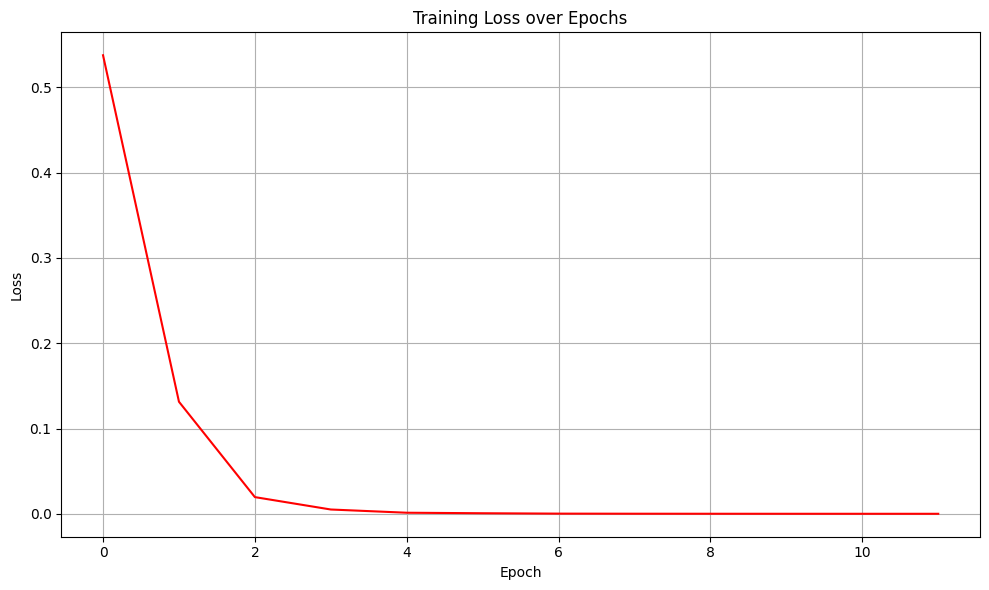

In [21]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

In [22]:
from util import show_table

show_table(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,2728,2608,0.9560
1,1,2728,2713,0.9945
2,2,2728,2727,0.9996
3,3,2728,2728,1.0000
4,4,2728,2728,1.0000
5,5,2728,2728,1.0000
6,6,2728,2728,1.0000
7,7,2728,2728,1.0000
8,8,2728,2728,1.0000
9,9,2728,2728,1.0000


## 训练后评估

In [23]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2728.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │            1.0            │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0, 'total_correct': 2728.0, 'val_overall_acc': 1.0}]

## 使用模型进行预测

In [24]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from util import print_classification_results

# 1. 准备需要预测的文本（长短不一）
new_texts = [
    # 短文本（5-10个字符）
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本（10-20个字符）
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本（20个字符以上）
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]


# 2. 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in new_texts:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)


# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_results(new_texts, true_labels, predictions, probabilities, model.label_map)


🎯 分类预测结果 (准确率: 9/10 = 90.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   正面   |  1.0000  |  ☑   |
|                      质量差                      |   负面   |   负面   |  0.9997  |  ☑   |
|                     推荐购买                     |   正面   |   正面   |  0.9688  |  ☑   |
|                     不建议买                     |   负面   |   负面   |  0.9996  |  ☑   |
|                  这个产品还不错                  |   正面   |   负面   |  0.9576  |  ☒   |
|                  物流速度太慢了                  |   负面   |   负面   |  1.0000  |  ☑   |
|                性价比很高值得推荐                |   正面   |   正面   |  0.5130  |  ☑   |
| 包装很精美，产品和描述一致，非常满意这次购物体验 |   正面   |   正面   |  1.0000  |  ☑   |
| 卖家服务态度不好，发货速度慢，产品质量也不如预期 |   负面   |   负面   |  0.9961

## 模型测试

In [25]:
from util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="../dataset/shopping_comments/dev.txt",
                             val_data_file="../dataset/shopping_comments/test.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在测试集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2728.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │            1.0            │
└───────────────────────────┴───────────────────────────┘

在测试集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2277.0           │
│       total_samples       │          2789.0           │
│      val_overall_acc      │     0.816421627998352     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2789.0,
  'total_correct': 2277.0,
  'val_overall_acc': 0.816421627998352}]

## 拓展阅读

## 存在的问题

思考一下，引出下一章